In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
df = pd.read_excel("Telco_customer_churn.xlsx")

In [48]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [49]:
df = df.drop(['CustomerID','Count','Country','State','City','Zip Code','Lat Long','Latitude','Longitude','Churn Reason','Churn Label','Churn Score','CLTV'],axis=1)

In [51]:
df.sample(5)

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
6228,Female,No,No,No,6,Yes,No,Fiber optic,No,No,Yes,Yes,No,Yes,Month-to-month,Yes,Electronic check,89.25,487.05,0
4242,Female,No,Yes,Yes,41,No,No phone service,DSL,Yes,No,Yes,No,No,No,One year,No,Credit card (automatic),35.40,1412.4,0
6401,Male,No,No,No,2,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Electronic check,19.65,31.2,0
1582,Male,Yes,Yes,No,3,Yes,Yes,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,94.60,279.55,1
5193,Female,No,Yes,No,72,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Mailed check,26.00,1776,0


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null   object 
 16  Payment Method     7043 

In [53]:
df.describe()

,Tenure Months,Monthly Charges,Churn Value
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,0.265370
std,24.559481,30.090047,0.441561
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,0.000000
50%,29.000000,70.350000,0.000000
75%,55.000000,89.850000,1.000000
max,72.000000,118.750000,1.000000


In [54]:
df['Total Charges'] =pd.to_numeric(df['Total Charges'],errors='coerce')

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null   object 
 16  Payment Method     7043 

In [56]:
df.describe()

,Tenure Months,Monthly Charges,Total Charges,Churn Value
count,7043.000000,7043.000000,7032.000000,7043.000000
mean,32.371149,64.761692,2283.300441,0.265370
std,24.559481,30.090047,2266.771362,0.441561
min,0.000000,18.250000,18.800000,0.000000
25%,9.000000,35.500000,401.450000,0.000000
50%,29.000000,70.350000,1397.475000,0.000000
75%,55.000000,89.850000,3794.737500,1.000000
max,72.000000,118.750000,8684.800000,1.000000


In [57]:
df.isnull().sum()

Gender                0
Senior Citizen        0
Partner               0
Dependents            0
Tenure Months         0
Phone Service         0
Multiple Lines        0
Internet Service      0
Online Security       0
Online Backup         0
Device Protection     0
Tech Support          0
Streaming TV          0
Streaming Movies      0
Contract              0
Paperless Billing     0
Payment Method        0
Monthly Charges       0
Total Charges        11
Churn Value           0
dtype: int64

In [58]:
median_val = df['Total Charges'].median()
median_val

1397.475

In [59]:
df['Total Charges'] = df['Total Charges'].fillna(median_val)

In [60]:
df['Total Charges'].isnull().sum()

np.int64(0)

In [61]:
df.isnull().sum()

Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Value          0
dtype: int64

In [64]:
x = df.drop('Churn Value',axis=1)
y = df['Churn Value']

In [65]:
from sklearn.preprocessing import LabelEncoder

In [66]:
le = LabelEncoder()

for col in x.columns:
    if x[col].dtype == 'object':
        x[col] = le.fit_transform(x[col])

In [67]:
from sklearn.model_selection import train_test_split


In [68]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [69]:
from sklearn.preprocessing import StandardScaler

In [70]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.fit_transform(x_test)

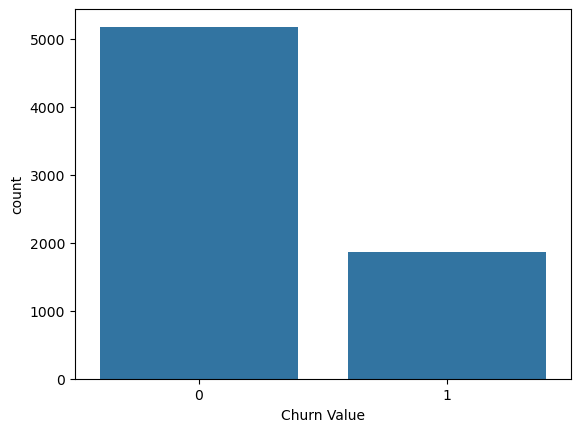

In [71]:
sns.countplot(x='Churn Value', data=df)
plt.show()

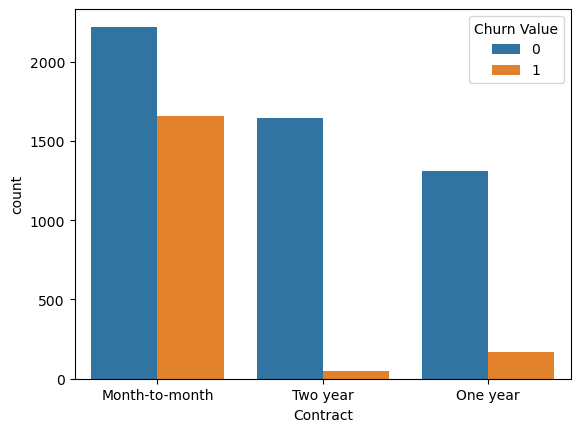

In [72]:
sns.countplot(x='Contract', hue='Churn Value', data=df)
plt.show()

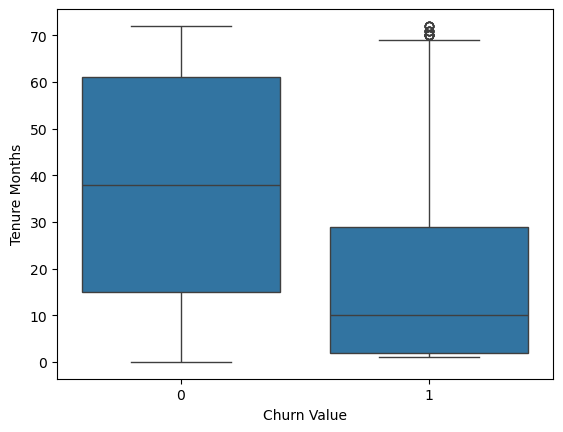

In [73]:
sns.boxplot(x='Churn Value', y='Tenure Months', data=df)
plt.show()

In [74]:
from sklearn.ensemble import RandomForestClassifier

In [75]:
model = RandomForestClassifier()
model.fit(x_train, y_train)

RandomForestClassifier()

In [76]:
y_pred = model.predict(x_test)

In [77]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [78]:
print("accuracy:", accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

accuracy: 0.7856635911994322
[[910  99]
 [203 197]]
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1009
           1       0.67      0.49      0.57       400

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.77      0.79      0.77      1409



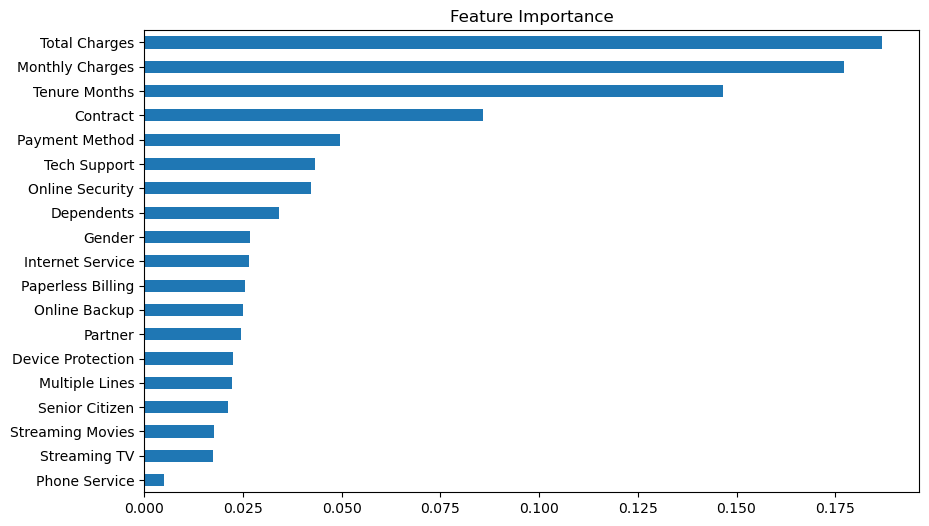

In [79]:
importance = pd.Series(model.feature_importances_, index=x.columns)
importance.sort_values().plot(kind='barh',figsize=(10,6))
plt.title("Feature Importance")
plt.show()

In [80]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression()

lr.fit(x_train, y_train)

y_pred_lr = lr.predict(x_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8005677785663591


In [81]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

dt.fit(x_train, y_train)

y_pred_dt = dt.predict(x_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7310149041873669


In [82]:
from sklearn.svm import SVC

svm = SVC()

svm.fit(x_train, y_train)

y_pred_svm = svm.predict(x_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.7927608232789212


In [83]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(x_train, y_train)

y_pred_knn = knn.predict(x_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.7629524485450674


In [86]:
import pickle

In [87]:
pickle.dump(lr,open("churn_model.pkl","wb"))